<a href="https://colab.research.google.com/github/habibiputrar/DeepLearning_B_2411531001_Habibi-Putra-Rizqullah/blob/main/Praktikum4/2411531001_Habibi_Putra_Rizqullah_Program4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum Deep Learning Minggu 4
## Long Short-Term Memory untuk Prediksi Deret Waktu

**Nama:** Habibi Putra Rizqullah  
**NIM:** 2411531001  
**Kelas:** Deep Learning B



# BAGIAN I PRAKTIKUM

Pada bagian ini dilakukan prediksi deret waktu sinus menggunakan RNN dan LSTM. Nilai MSE dipakai sebagai ukuran kesalahan karena keluaran model berupa nilai kontinu, bukan kelas.


## 1. Persiapan Library dan Perangkat

Pada sel ini dilakukan import library yang diperlukan untuk proses eksperimen. Selain itu, `seed` ditentukan agar hasil yang diperoleh tetap konsisten saat kode dijalankan kembali. Program juga akan menggunakan GPU apabila tersedia. Sebelum menjalankan setiap eksperimen, fungsi `set_seed()` dipanggil kembali agar kondisi awalnya tetap sama, sehingga hasil dari setiap percobaan dapat dibandingkan dengan lebih mudah.



In [ ]:
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Perangkat yang digunakan: {device}")


Perangkat yang digunakan: cuda


## 2. Membuat Dataset Sinus

Data dibuat dari fungsi sinus dengan 1.000 titik. Pola ini dipilih karena bersifat berurutan dan memiliki bentuk periodik yang jelas, sehingga cocok untuk latihan awal prediksi deret waktu.


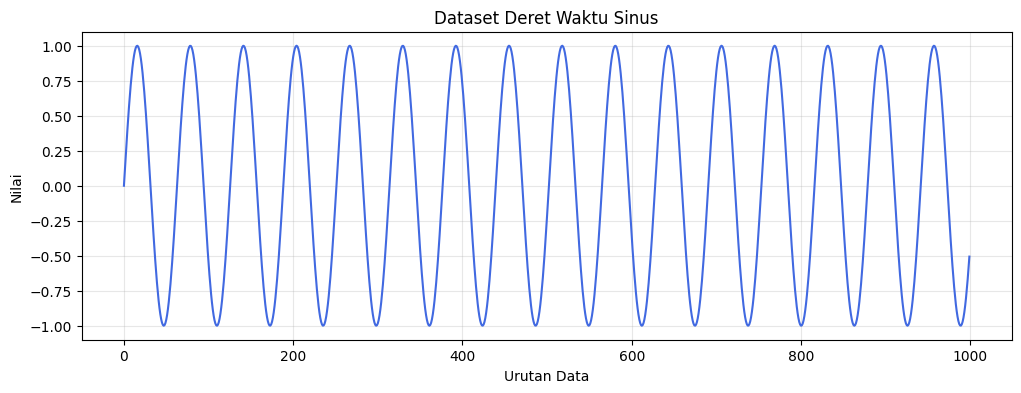

In [ ]:
jumlah_titik = 1000
rentang = np.linspace(0, 100, jumlah_titik, dtype=np.float32)
data_sinus = np.sin(rentang).astype(np.float32)

plt.figure(figsize=(12, 4))
plt.plot(data_sinus, color="royalblue")
plt.title("Dataset Deret Waktu Sinus")
plt.xlabel("Urutan Data")
plt.ylabel("Nilai")
plt.grid(alpha=0.3)
plt.show()


## 3. Membentuk Sequence dan Membagi Data

Pada proses ini, 20 nilai sebelumnya digunakan untuk memprediksi nilai berikutnya. Data kemudian dibagi secara berurutan, dengan 80 persen digunakan untuk training dan 20 persen untuk testing. Data tidak diacak karena urutan waktu perlu tetap dipertahankan dalam proses prediksi.



In [ ]:
def create_sequences(data, seq_length=20):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        xs.append(data[i:i + seq_length])
        ys.append(data[i + seq_length])

    X = np.asarray(xs, dtype=np.float32)[..., np.newaxis]
    y = np.asarray(ys, dtype=np.float32)[..., np.newaxis]
    return X, y


def prepare_data(data, seq_length=20, train_ratio=0.8):
    X, y = create_sequences(data, seq_length)
    batas_train = int(len(X) * train_ratio)

    X_train = torch.from_numpy(X[:batas_train]).to(device)
    y_train = torch.from_numpy(y[:batas_train]).to(device)
    X_test = torch.from_numpy(X[batas_train:]).to(device)
    y_test = torch.from_numpy(y[batas_train:]).to(device)
    return X_train, y_train, X_test, y_test, batas_train


SEQ_LENGTH = 20
X_train, y_train, X_test, y_test, batas_train = prepare_data(
    data_sinus, seq_length=SEQ_LENGTH
)

print(f"Bentuk X training : {tuple(X_train.shape)}")
print(f"Bentuk y training : {tuple(y_train.shape)}")
print(f"Bentuk X testing  : {tuple(X_test.shape)}")
print(f"Bentuk y testing  : {tuple(y_test.shape)}")


Bentuk X training : (784, 20, 1)
Bentuk y training : (784, 1)
Bentuk X testing  : (196, 20, 1)
Bentuk y testing  : (196, 1)


## 4. Membuat Model RNN dan LSTM

RNN dipakai sebagai model pembanding dari praktikum sebelumnya. LSTM memiliki mekanisme cell state dan gate yang membantu mempertahankan informasi penting dalam urutan yang lebih panjang. Kedua model menggunakan hidden size dan jumlah layer yang dapat diubah saat eksperimen.


In [ ]:
class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, output_size=1, num_layers=1):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])


class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, output_size=1, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


## 5. Membuat Fungsi Training dan Evaluasi

Fungsi training menjalankan forward pass, menghitung MSE, melakukan backpropagation, dan memperbarui bobot dengan Adam. Fungsi evaluasi menggunakan mode evaluasi dan `torch.no_grad()` agar gradien tidak dihitung saat pengujian.


In [ ]:
def train_model(model, X_train, y_train, epochs=50, learning_rate=0.01, verbose=True):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = []

    start_time = time.perf_counter()
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        predictions = model(X_train)
        loss = criterion(predictions, y_train)
        loss.backward()
        optimizer.step()

        history.append(loss.item())
        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch + 1:02d}/{epochs}] | Loss: {loss.item():.6f}")

    training_time = time.perf_counter() - start_time
    return history, training_time


def evaluate_model(model, X_test, y_test):
    model.eval()
    criterion = nn.MSELoss()
    with torch.no_grad():
        predictions = model(X_test)
        mse = criterion(predictions, y_test).item()
    return predictions.detach().cpu().numpy().ravel(), mse


## 6. Melatih RNN dan LSTM Dasar

RNN dan LSTM dilatih dengan konfigurasi yang sama, yaitu hidden size 64, satu layer, 50 epoch, dan learning rate 0,01. Konfigurasi yang sama membantu menunjukkan perbedaan arsitektur tanpa dipengaruhi parameter pelatihan yang berbeda.


In [ ]:
EPOCHS = 50
LEARNING_RATE = 0.01

set_seed()
rnn_model = RNNModel(hidden_size=64, num_layers=1)
print("Training RNN")
rnn_losses, rnn_time = train_model(
    rnn_model, X_train, y_train, EPOCHS, LEARNING_RATE
)
rnn_predictions, rnn_mse = evaluate_model(rnn_model, X_test, y_test)

set_seed()
lstm_model = LSTMModel(hidden_size=64, num_layers=1)
print("\nTraining LSTM")
lstm_losses, lstm_time = train_model(
    lstm_model, X_train, y_train, EPOCHS, LEARNING_RATE
)
lstm_predictions, lstm_mse = evaluate_model(lstm_model, X_test, y_test)

print("\nHasil pengujian")
print(f"RNN  | MSE testing: {rnn_mse:.6f} | Waktu training: {rnn_time:.2f} detik")
print(f"LSTM | MSE testing: {lstm_mse:.6f} | Waktu training: {lstm_time:.2f} detik")


Training RNN
Epoch [10/50] | Loss: 0.031718
Epoch [20/50] | Loss: 0.017357
Epoch [30/50] | Loss: 0.002829
Epoch [40/50] | Loss: 0.001083
Epoch [50/50] | Loss: 0.000073

Training LSTM
Epoch [10/50] | Loss: 0.033891
Epoch [20/50] | Loss: 0.003125
Epoch [30/50] | Loss: 0.002594
Epoch [40/50] | Loss: 0.000390
Epoch [50/50] | Loss: 0.000427

Hasil pengujian
RNN  | MSE testing: 0.000364 | Waktu training: 1.35 detik
LSTM | MSE testing: 0.000282 | Waktu training: 0.16 detik


## 7. Menampilkan Kurva Loss

Kurva loss memperlihatkan perubahan kesalahan training pada setiap epoch. Kurva yang turun menunjukkan bahwa model mempelajari pola data. Perbandingan ini juga digunakan untuk melihat kestabilan proses training RNN dan LSTM.


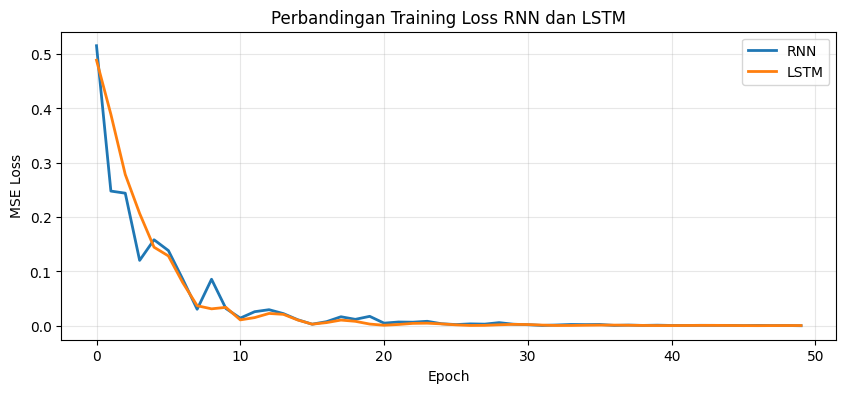

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(rnn_losses, label="RNN", linewidth=2)
plt.plot(lstm_losses, label="LSTM", linewidth=2)
plt.title("Perbandingan Training Loss RNN dan LSTM")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 8. Menampilkan Hasil Prediksi

Grafik ini menunjukkan perbandingan antara nilai asli pada data testing dengan hasil prediksi dari model RNN dan LSTM. Semakin dekat garis prediksi dengan data asli, berarti hasil prediksinya semakin mendekati nilai sebenarnya.



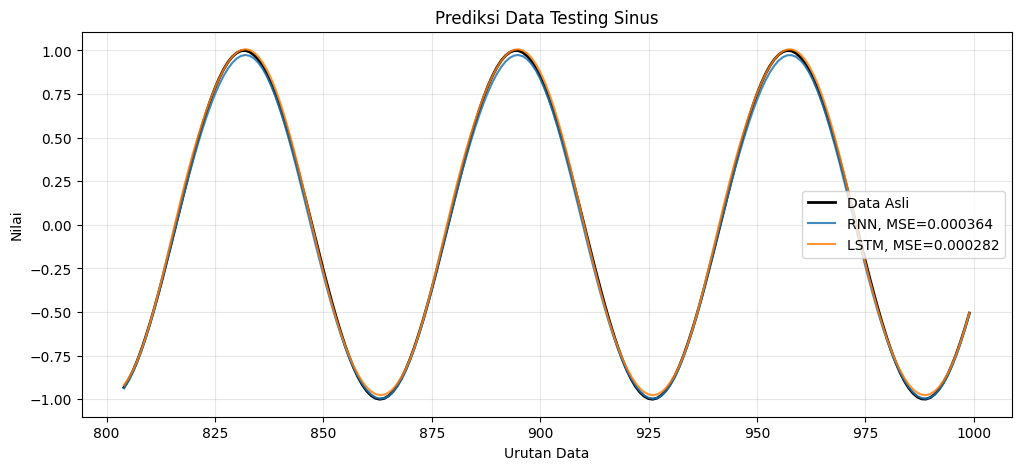

In [ ]:
y_test_numpy = y_test.detach().cpu().numpy().ravel()
indeks_test = np.arange(batas_train + SEQ_LENGTH, len(data_sinus))

plt.figure(figsize=(12, 5))
plt.plot(indeks_test, y_test_numpy, label="Data Asli", color="black", linewidth=2)
plt.plot(indeks_test, rnn_predictions, label=f"RNN, MSE={rnn_mse:.6f}", alpha=0.85)
plt.plot(indeks_test, lstm_predictions, label=f"LSTM, MSE={lstm_mse:.6f}", alpha=0.85)
plt.title("Prediksi Data Testing Sinus")
plt.xlabel("Urutan Data")
plt.ylabel("Nilai")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 9. Eksperimen Hidden Size

Modul meminta percobaan hidden size 32, 64, dan 128. Model dengan hidden size 64 memakai hasil LSTM dasar, sedangkan ukuran 32 dan 128 dilatih dengan pengaturan yang sama. Selain MSE, waktu training dicatat untuk melihat pengaruh kapasitas model terhadap efisiensi.


In [ ]:
hasil_hidden = []
model_hidden = {}

for hidden_size in [32, 64, 128]:
    if hidden_size == 64:
        model_eksperimen = lstm_model
        losses = lstm_losses
        waktu = lstm_time
        predictions = lstm_predictions
        mse = lstm_mse
    else:
        set_seed()
        model_eksperimen = LSTMModel(hidden_size=hidden_size, num_layers=1)
        print(f"Training LSTM dengan hidden size {hidden_size}")
        losses, waktu = train_model(
            model_eksperimen,
            X_train,
            y_train,
            epochs=EPOCHS,
            learning_rate=LEARNING_RATE,
            verbose=False,
        )
        predictions, mse = evaluate_model(model_eksperimen, X_test, y_test)

    model_hidden[hidden_size] = {
        "model": model_eksperimen,
        "losses": losses,
        "predictions": predictions,
    }
    hasil_hidden.append({
        "Hidden Size": hidden_size,
        "Num Layers": 1,
        "Loss Akhir Training": losses[-1],
        "MSE Testing": mse,
        "Waktu Training (s)": waktu,
    })

tabel_hidden = pd.DataFrame(hasil_hidden).round(6)
tabel_hidden


Training LSTM dengan hidden size 32
Training LSTM dengan hidden size 128


,Hidden Size,Num Layers,Loss Akhir Training,MSE Testing,Waktu Training (s)
0,32,1,0.000529,0.000647,0.137526
1,64,1,0.000427,0.000282,0.156210
2,128,1,0.000191,0.000211,0.418476


## 10. Visualisasi Eksperimen Hidden Size

Grafik pertama menunjukkan kurva loss setiap hidden size. Grafik kedua menunjukkan perbandingan MSE testing. Nilai MSE yang lebih kecil menandakan prediksi yang lebih mendekati data asli.


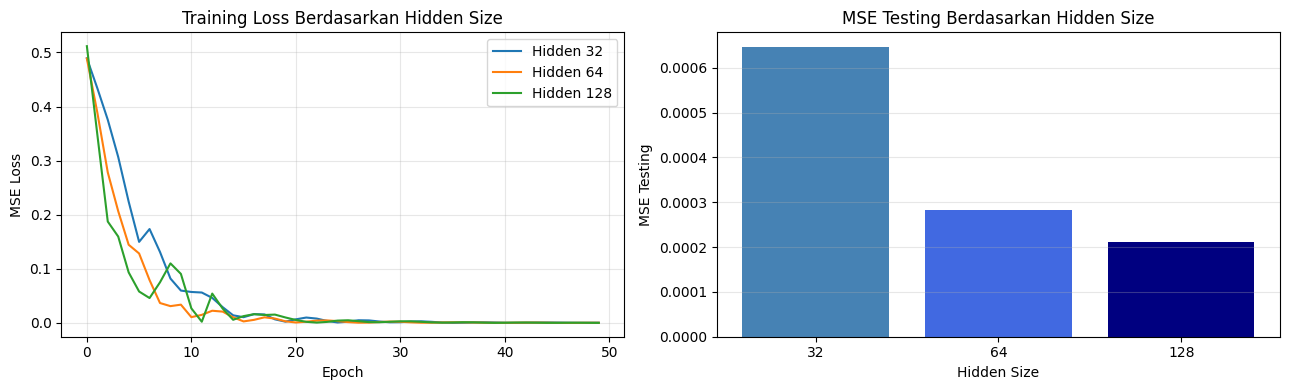

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for hidden_size, info in model_hidden.items():
    axes[0].plot(info["losses"], label=f"Hidden {hidden_size}")
axes[0].set_title("Training Loss Berdasarkan Hidden Size")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].bar(
    tabel_hidden["Hidden Size"].astype(str),
    tabel_hidden["MSE Testing"],
    color=["steelblue", "royalblue", "navy"],
)
axes[1].set_title("MSE Testing Berdasarkan Hidden Size")
axes[1].set_xlabel("Hidden Size")
axes[1].set_ylabel("MSE Testing")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


## 11. Analisis Hasil Praktikum

Sel ini membuat ringkasan berdasarkan hasil yang benar-benar diperoleh setelah notebook dijalankan. Kesimpulan tidak hanya melihat loss terkecil, tetapi juga mempertimbangkan waktu training.


In [ ]:
model_terbaik_hidden = tabel_hidden.loc[tabel_hidden["MSE Testing"].idxmin()]

print("Analisis hasil praktikum")
if lstm_mse < rnn_mse:
    print(f"1. LSTM memperoleh MSE testing lebih rendah daripada RNN dengan selisih {rnn_mse - lstm_mse:.6f}.")
elif lstm_mse > rnn_mse:
    print(f"1. Pada data sederhana ini, RNN memperoleh MSE testing lebih rendah daripada LSTM dengan selisih {lstm_mse - rnn_mse:.6f}.")
else:
    print("1. RNN dan LSTM memperoleh MSE testing yang sama.")

print(
    f"2. Hidden size terbaik pada percobaan ini adalah {int(model_terbaik_hidden['Hidden Size'])} "
    f"dengan MSE testing {model_terbaik_hidden['MSE Testing']:.6f}."
)
print(
    "3. Penambahan hidden size meningkatkan kapasitas model, tetapi hasilnya tidak selalu lebih baik "
    "dan waktu training cenderung bertambah."
)
print(
    "4. Kurva prediksi perlu dilihat bersama nilai MSE karena kurva yang tampak halus belum tentu "
    "memiliki kesalahan paling kecil."
)


Analisis hasil praktikum
1. LSTM memperoleh MSE testing lebih rendah daripada RNN dengan selisih 0.000082.
2. Hidden size terbaik pada percobaan ini adalah 128 dengan MSE testing 0.000211.
3. Penambahan hidden size meningkatkan kapasitas model, tetapi hasilnya tidak selalu lebih baik dan waktu training cenderung bertambah.
4. Kurva prediksi perlu dilihat bersama nilai MSE karena kurva yang tampak halus belum tentu memiliki kesalahan paling kecil.


# BAGIAN II TUGAS INDIVIDU

Pada tugas individu, dataset diganti menjadi fungsi cosinus. Tiga konfigurasi LSTM dibandingkan untuk melihat pengaruh hidden size dan penambahan layer terhadap loss serta waktu training.


## 1. Membuat Dataset Cosinus

Jumlah titik dan rentang data dibuat sama seperti bagian praktikum. Perubahan hanya dilakukan pada fungsi pembangkit data, yaitu dari sinus menjadi cosinus, agar perbandingan konfigurasi tetap konsisten.


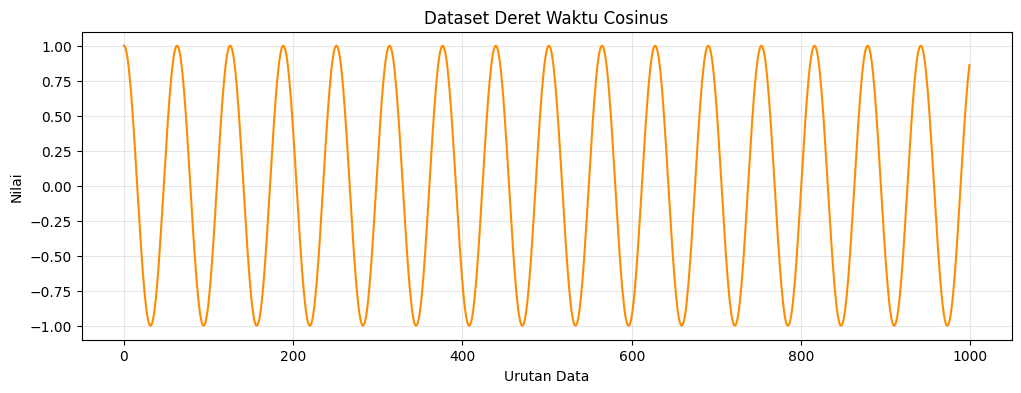

In [ ]:
data_cosinus = np.cos(rentang).astype(np.float32)

plt.figure(figsize=(12, 4))
plt.plot(data_cosinus, color="darkorange")
plt.title("Dataset Deret Waktu Cosinus")
plt.xlabel("Urutan Data")
plt.ylabel("Nilai")
plt.grid(alpha=0.3)
plt.show()


## 2. Menyiapkan Data Cosinus

Data cosinus dibentuk menjadi sequence sepanjang 20 dan dibagi secara berurutan menjadi data training serta testing. Cara ini sama dengan bagian praktikum agar hasil eksperimen dapat dibandingkan dengan dasar yang sama.


In [ ]:
X_train_cos, y_train_cos, X_test_cos, y_test_cos, batas_train_cos = prepare_data(
    data_cosinus, seq_length=SEQ_LENGTH
)

print(f"Jumlah sequence training: {len(X_train_cos)}")
print(f"Jumlah sequence testing : {len(X_test_cos)}")


Jumlah sequence training: 784
Jumlah sequence testing : 196


## 3. Menjalankan Tiga Eksperimen LSTM

LSTM 1 menggunakan hidden size 32 dan satu layer. LSTM 2 menggunakan hidden size 64 dan satu layer. LSTM 3 menggunakan hidden size 64 dan dua layer sesuai instruksi tugas. Semua model memakai epoch dan learning rate yang sama.


In [ ]:
konfigurasi_tugas = [
    {"Model": "LSTM_1", "Hidden Size": 32, "Num Layers": 1},
    {"Model": "LSTM_2", "Hidden Size": 64, "Num Layers": 1},
    {"Model": "LSTM_3", "Hidden Size": 64, "Num Layers": 2},
]

hasil_tugas = []
detail_tugas = {}

for config in konfigurasi_tugas:
    set_seed()
    model_tugas = LSTMModel(
        hidden_size=config["Hidden Size"],
        num_layers=config["Num Layers"],
    )

    print(
        f"Training {config['Model']} | hidden={config['Hidden Size']} | "
        f"layers={config['Num Layers']}"
    )
    losses, waktu = train_model(
        model_tugas,
        X_train_cos,
        y_train_cos,
        epochs=EPOCHS,
        learning_rate=LEARNING_RATE,
        verbose=False,
    )
    predictions, mse = evaluate_model(
        model_tugas, X_test_cos, y_test_cos
    )

    catatan = (
        "Model lebih ringan"
        if config["Hidden Size"] == 32
        else "Kapasitas hidden lebih besar"
        if config["Num Layers"] == 1
        else "Menggunakan dua layer LSTM"
    )

    hasil_tugas.append({
        "Model": config["Model"],
        "Hidden Size": config["Hidden Size"],
        "Num Layers": config["Num Layers"],
        "Loss Akhir": losses[-1],
        "MSE Testing": mse,
        "Waktu Training (s)": waktu,
        "Catatan": catatan,
    })
    detail_tugas[config["Model"]] = {
        "model": model_tugas,
        "losses": losses,
        "predictions": predictions,
    }

tabel_tugas = pd.DataFrame(hasil_tugas)
tabel_tugas_tampil = tabel_tugas.copy()
tabel_tugas_tampil[["Loss Akhir", "MSE Testing", "Waktu Training (s)"]] = (
    tabel_tugas_tampil[["Loss Akhir", "MSE Testing", "Waktu Training (s)"]].round(6)
)
tabel_tugas_tampil


Training LSTM_1 | hidden=32 | layers=1
Training LSTM_2 | hidden=64 | layers=1
Training LSTM_3 | hidden=64 | layers=2


,Model,Hidden Size,Num Layers,Loss Akhir,MSE Testing,Waktu Training (s),Catatan
0,LSTM_1,32,1,0.000452,0.000577,0.106139,Model lebih ringan
1,LSTM_2,64,1,0.000255,0.000205,0.111731,Kapasitas hidden lebih besar
2,LSTM_3,64,2,0.001538,0.001253,0.167531,Menggunakan dua layer LSTM


## 4. Membandingkan Kurva Loss dan MSE

Kurva loss digunakan untuk melihat proses konvergensi setiap model. Diagram batang membantu membandingkan MSE testing secara langsung. Model dengan MSE terendah dipilih sebagai model terbaik pada data cosinus.


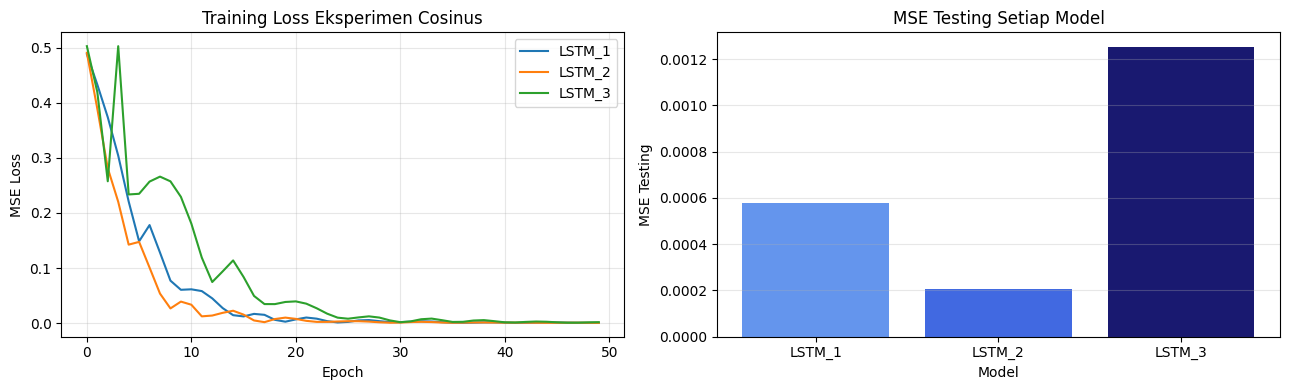

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for nama_model, info in detail_tugas.items():
    axes[0].plot(info["losses"], label=nama_model)
axes[0].set_title("Training Loss Eksperimen Cosinus")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].bar(
    tabel_tugas["Model"],
    tabel_tugas["MSE Testing"],
    color=["cornflowerblue", "royalblue", "midnightblue"],
)
axes[1].set_title("MSE Testing Setiap Model")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("MSE Testing")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Menampilkan Prediksi Model Terbaik

Model dengan MSE testing paling kecil dipilih secara otomatis. Prediksinya kemudian dibandingkan dengan nilai asli pada bagian data testing.


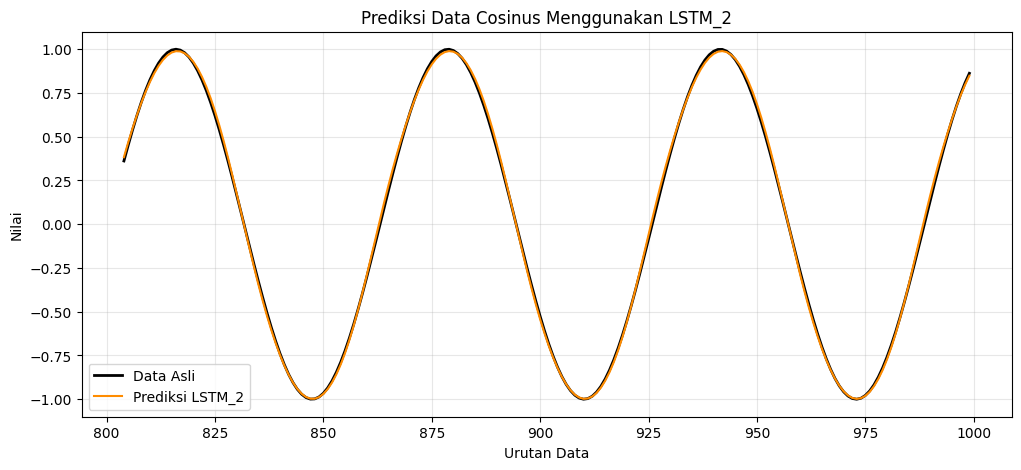

Model terbaik: LSTM_2 | MSE testing: 0.000205


In [ ]:
baris_terbaik = tabel_tugas.loc[tabel_tugas["MSE Testing"].idxmin()]
nama_terbaik = baris_terbaik["Model"]
prediksi_terbaik = detail_tugas[nama_terbaik]["predictions"]
y_test_cos_numpy = y_test_cos.detach().cpu().numpy().ravel()
indeks_test_cos = np.arange(batas_train_cos + SEQ_LENGTH, len(data_cosinus))

plt.figure(figsize=(12, 5))
plt.plot(indeks_test_cos, y_test_cos_numpy, label="Data Asli", color="black", linewidth=2)
plt.plot(
    indeks_test_cos,
    prediksi_terbaik,
    label=f"Prediksi {nama_terbaik}",
    color="darkorange",
)
plt.title(f"Prediksi Data Cosinus Menggunakan {nama_terbaik}")
plt.xlabel("Urutan Data")
plt.ylabel("Nilai")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(
    f"Model terbaik: {nama_terbaik} | "
    f"MSE testing: {baris_terbaik['MSE Testing']:.6f}"
)


## 6. Analisis Pengaruh Penambahan Layer

Analisis dibuat dari hasil LSTM 2 dan LSTM 3 karena kedua model menggunakan hidden size 64. Dengan demikian, perbedaan utama di antara keduanya adalah jumlah layer.


In [ ]:
lstm_2 = tabel_tugas[tabel_tugas["Model"] == "LSTM_2"].iloc[0]
lstm_3 = tabel_tugas[tabel_tugas["Model"] == "LSTM_3"].iloc[0]

selisih_mse = lstm_3["MSE Testing"] - lstm_2["MSE Testing"]
selisih_waktu = lstm_3["Waktu Training (s)"] - lstm_2["Waktu Training (s)"]

print("Analisis penambahan layer")
if selisih_mse < 0:
    print(f"1. Dua layer menurunkan MSE testing sebesar {abs(selisih_mse):.6f}.")
elif selisih_mse > 0:
    print(f"1. Dua layer menaikkan MSE testing sebesar {selisih_mse:.6f}.")
else:
    print("1. Satu layer dan dua layer menghasilkan MSE testing yang sama.")

if selisih_waktu > 0:
    print(f"2. LSTM dua layer membutuhkan waktu training {selisih_waktu:.2f} detik lebih lama.")
else:
    print(f"2. Pada proses ini, LSTM dua layer selesai {abs(selisih_waktu):.2f} detik lebih cepat.")

print(
    "3. Penambahan layer meningkatkan kedalaman model dan jumlah komputasi. "
    "Namun, model yang lebih dalam tidak selalu memberikan MSE yang lebih rendah pada data sederhana."
)


Analisis penambahan layer
1. Dua layer menaikkan MSE testing sebesar 0.001048.
2. LSTM dua layer membutuhkan waktu training 0.06 detik lebih lama.
3. Penambahan layer meningkatkan kedalaman model dan jumlah komputasi. Namun, model yang lebih dalam tidak selalu memberikan MSE yang lebih rendah pada data sederhana.


## 7. Kesimpulan Tugas Individu

Berdasarkan eksperimen, LSTM dapat mempelajari pola periodik pada data cosinus. Penambahan hidden size memberi model kapasitas yang lebih besar, sedangkan penambahan layer membuat proses pengolahan urutan menjadi lebih dalam. Akan tetapi, konfigurasi yang lebih besar tidak otomatis menjadi pilihan terbaik karena nilai MSE juga dipengaruhi proses optimasi dan karakteristik data.

Untuk data sinus dan cosinus yang sederhana, RNN masih dapat memberikan hasil yang baik. Keunggulan LSTM biasanya lebih terlihat pada urutan yang lebih panjang atau pola yang memiliki dependensi jangka panjang. Oleh karena itu, keputusan bahwa LSTM lebih unggul harus didasarkan pada hasil pengujian, bukan hanya pada jumlah layer model.


## 8. Jawaban Pertanyaan Reflektif

### 1. Apa peran cell state dalam LSTM?

Cell state berfungsi sebagai tempat penyimpanan informasi yang dibawa dari satu langkah waktu ke langkah berikutnya. Informasi tersebut diatur oleh beberapa gate, terutama forget gate dan input gate. Dengan begitu, model dapat mempertahankan informasi yang masih dibutuhkan dan menghapus informasi yang sudah tidak diperlukan.

### 2. Mengapa LSTM lebih mampu mengingat konteks jangka panjang dibanding RNN?

LSTM memiliki cell state dan beberapa gate yang mengatur informasi yang masuk, disimpan, dan dikeluarkan dari memori. Hal ini membuat aliran informasi selama proses training lebih terjaga dan dapat mengurangi masalah vanishing gradient. Pada RNN biasa, informasi dari langkah sebelumnya lebih mudah berkurang ketika urutan datanya semakin panjang.

### 3. Apa dampak penambahan jumlah layer terhadap hasil dan waktu training?

Penambahan layer membuat model memiliki kemampuan untuk mempelajari pola yang lebih kompleks. Namun, semakin banyak layer yang digunakan, proses training juga membutuhkan waktu dan komputasi yang lebih besar. Pada data yang sederhana, penambahan layer belum tentu memberikan hasil yang lebih baik dan justru bisa membuat model terlalu kompleks.
